# Actividad grupal Python
## Inteligencia artificial con Python
*Rita Pellissa Valera, Samuel Pintos González, Tamara Noya Mosquera, Vanesa de las Heras Hermosilla, Virginia García-Loygorri Arias y Yannis Avlonitis Egea.*

Para inicializar el entorno de desarrollo, se accedió a la plataforma oficial de Google Colab mediante una cuenta activa de Google Drive y se creó el nuevo cuaderno (Grupo27.ipynb) alojado en la nube.

Acto seguido, con la función "Compartir" para introducir las direcciones de correo electrónico de los otros 5 integrantes del equipo, otorgando de manera explícita el rol de "Editor" a cada usuario para habilitar el desarrollo colaborativo y simultáneo del pipeline.

## 1. Implementación de algoritmos de aprendizaje automático

### A. Importación de librerías y preprocesamiento de datos

In [ ]:
# Librerías
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report

# Datos iris de Seaborn
iris = sns.load_dataset('iris')



In [ ]:

# One Hot Encoding
# -------------------------

# pd.get_dummies para realizar la transformación de forma directa
iris_encoded = pd.get_dummies(iris, columns=['species'], dtype=int)

# Predictoras (X) vs variables objetivo vectorizadas (Y)
# Nuevas columnas = 'species_setosa', 'species_versicolor' y 'species_virginica'
X = iris_encoded.drop(columns=['species_setosa', 'species_versicolor', 'species_virginica'])
y = iris_encoded[['species_setosa', 'species_versicolor', 'species_virginica']]


In [ ]:

# Separación test - train
# -------------------------

# 20% test + 80% training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Para ver si ha partido bien el test y training
print(f"Muestras para entrenamiento (80%): {X_train.shape[0]}")
print(f"Muestras para testeo (20%): {X_test.shape[0]}")


Muestras para entrenamiento (80%): 120
Muestras para testeo (20%): 30


### B. Algoritmos de aprendizaje automático

Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


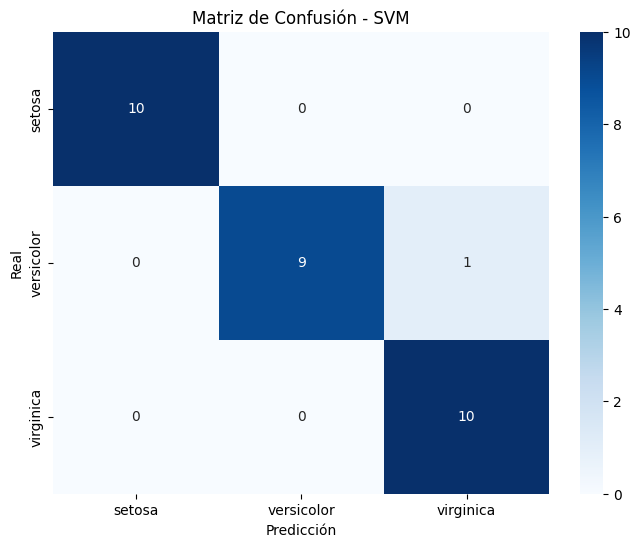


Informe de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


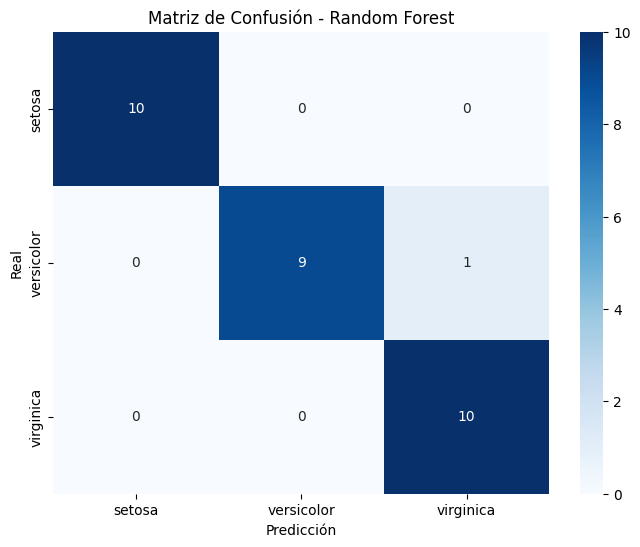


Informe de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


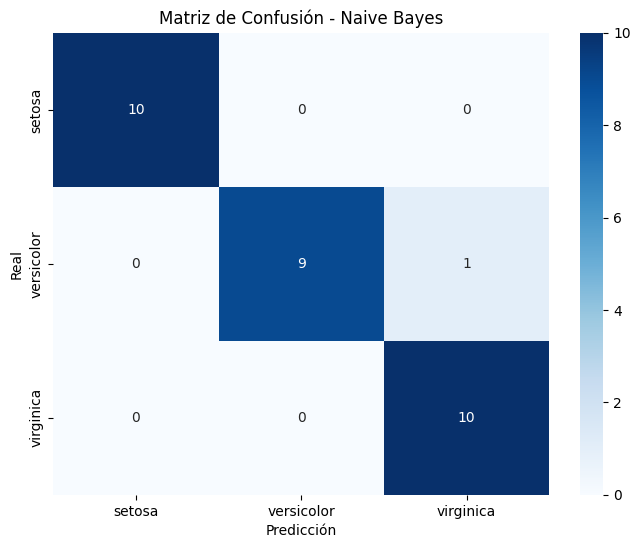


Informe de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
# Implementación y entreno de SVM, RF y NV
# ----------------------------

# Convertir el One Hot Encoding del apartado 2A a etiqueta entera mediante argmax
# argmax devuelve el índice de la columna con valor 1 en cada fila
# 0 = setosa, 1 = versicolor, 2 = virginica
y_train_labels = np.argmax(y_train.values, axis=1)
y_test_labels  = np.argmax(y_test.values,  axis=1)

species = ['setosa', 'versicolor', 'virginica']


# 1. Support Vector Machines
# ---------------------------
# Se utiliza el kernel de base radial RBF porque los datos no son linealmente separables
# en todas sus clases
# random_state: semilla de reproducibilidad
clf_svm = SVC(kernel='rbf', random_state=27)

# Entrenar el modelo con los datos de entrenamiento
clf_svm.fit(X_train, y_train_labels)

# Predecir las clases para los datos de test
y_pred_svm = clf_svm.predict(X_test)

# Matriz de confusión: filas = clase real, columnas = clase predicha
# Los valores en la diagonal son aciertos, fuera de ella son errores
conf_matrix_svm = confusion_matrix(y_test_labels, y_pred_svm)
print("Matriz de confusión:")
print(conf_matrix_svm)

# Matriz de confusión gráfica
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm, annot=True, fmt="d", cmap="Blues", xticklabels=species, yticklabels=species)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - SVM")
plt.show()

# Informe de clasificación(precision, recall y f1-score)
print("\nInforme de clasificación:")
print(classification_report(y_test_labels, y_pred_svm, target_names=species))


# 2. Random Forest
# -----------------
# Se construye un random forest de árboles de decisión, cada uno entrenado con una muestra
# aleatoria de los datos. La clase predicha es la que obtiene más votos entre todos los árboles
# n_estimators: número de árboles
# max_depth: profundidad máxima de cada árbol
clf_rf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=27)

# Entrenar el modelo
clf_rf.fit(X_train, y_train_labels)

# Predecir las clases para los datos de test
y_pred_rf = clf_rf.predict(X_test)

# Matriz de confusión
conf_matrix_rf = confusion_matrix(y_test_labels, y_pred_rf)
print("Matriz de confusión:")
print(conf_matrix_rf)

# Matriz de confusión gráfica
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Blues", xticklabels=species, yticklabels=species)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Random Forest")
plt.show()

# Informe de clasificación(precision, recall y f1-score)
print("\nInforme de clasificación:")
print(classification_report(y_test_labels, y_pred_rf, target_names=species))


# 3. Naive Bayes
# -----------------
# Se asume que cada característica sigue una distribución gaussiana dentro de cada clase
# y que todas las características son independientes entre sí
clf_nb = GaussianNB()

# Entrenar el modelo
clf_nb.fit(X_train, y_train_labels)

# Predecir las clases para los datos de test
y_pred_nb = clf_nb.predict(X_test)

# Matriz de confusión
conf_matrix_nb = confusion_matrix(y_test_labels, y_pred_nb)
print("Matriz de confusión:")
print(conf_matrix_nb)

# Matriz de confusión gráfica
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nb, annot=True, fmt="d", cmap="Blues", xticklabels=species, yticklabels=species)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Naive Bayes")
plt.show()

# Informe de clasificación(precision, recall y f1-score)
print("\nInforme de clasificación:")
print(classification_report(y_test_labels, y_pred_nb, target_names=species))



### C. Valoración de las predicciones

Se analizan los tres modelos de clasificación en función de las métricas Precision, Recall y  f1-score.

Los tres tienen el valor máximo de 1, tiene sentido ya que son valores preparados para practicar y no valores reales.
En teoría hay situaciones en las que es más aconsejable un modelo u otro.

SVM:Cuando tenemos un volumen de datos pequeño.

RF: Si los datos pertenecen a clases diferentes (categóricos, numéricos...) este sería una buena elección.

NB: Si tenemos un gran volumen de datos este sería un buen modelo siempre que las variables no estuviesen correlacionadas.

## 2. Implementación de algoritmos de aprendizaje automático profundo

### A. Preparación del Dataset y Preprocesamiento de Datos

In [ ]:
import matplotlib.pyplot as plt
import random
import tensorflow as tf
import cv2
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from time import sleep
import os
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import zipfile
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
# Carga de datos desde drive
from google.colab import drive
drive.mount('/content/drive')


# La carpeta final es /content/Malaria, que contiene:
#  /content/Malaria/Parasitized y /content/Malaria/Uninfected

zip_path = "/content/drive/MyDrive/Malaria_Data.zip"  # Cambia esto por la ruta a tu archivo ZIP
extract_path = "/content/"
dataset_path = "/content/Malaria"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Fijar el tamaño de imagen
IMG_SIZE = 100

# Directorio donde se encuentran los datos de imagen
DATA_DIR = "/content/Malaria/"

# Funcion que saca las imagenes de las carpetas y las redimensiona a 100x100
def load_images_from_folder(folder):
    data = []
    labels = []

    for label_name in os.listdir(folder):
        label_path = os.path.join(folder, label_name)

        # label_name puede ser "Parasitized" o "Uninfected"
        label = 0 if label_name == "Uninfected" else 1

        for img_name in os.listdir(label_path):
            img_path = os.path.join(label_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            print(f"\r{img_path}{img_name}", end='')
            if img is not None:
                # Redimensionar
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                # Normalizar a [0,1]
                img = (img / 255.0).astype(np.float32)

                data.append(img)
                labels.append(label)

    return np.array(data), np.array(labels)

image, label = load_images_from_folder(DATA_DIR)

# Guardado de datos de entrenamiento:
  # train
  # temp para guardarlos a modo temporal y dividirlos en test y validacion despues
image_train, image_test, label_train, label_test = train_test_split(
    image, label, test_size=0.30, random_state=42, stratify=label)

image_val, image_test, label_val, label_test = train_test_split(
    image_test, label_test, test_size=0.50, random_state=42, stratify=label_test)

/content/Malaria/Uninfected/C121P82ThinF_IMG_20151002_135237_cell_14.pngC121P82ThinF_IMG_20151002_135237_cell_14.png

### B. Diseño de la red neuronal convolucional (CNN) con Tensorflow

In [ ]:
# Importación de las librerías de TF y Keras

np.random.seed(2522)

# Diseño de la red
model_cnn = Sequential()
  # A Sequential model is appropriate for a plain stack of layers where each layer has exactly one input tensor and one output tensor.

# Primera capa convolucional
  # Las medidas son 100 x 100 por el número de píxeles y los 3 canales de color RGB -> !!! OpenCV arranges the channels in BGR order.
model_cnn.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(100, 100, 1)))
model_cnn.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

# Segunda capa convolucional
model_cnn.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

# Aplanar las características para conectarlas a una capa densa

model_cnn.add(Flatten())

model_cnn.add(Dropout(0.5))

# Capa densa con 128 neuronas
model_cnn.add(Dense(128, activation='relu'))

# Capa de salida con 1 neurona (con una función sigmoide, una respuesta para cada diagnóstico: "Parasitized" o "Uninfected")
model_cnn.add(Dense(1, activation='sigmoid'))

model_cnn.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model_cnn.summary()


# Entrenamiento del modelo
parada = EarlyStopping(
    monitor='val_loss',    # Vigila el error de validación
    patience=2,            # Si durante 2 épocas seguidas el error no baja, se detiene
    restore_best_weights=True # Devuelve a la red los mejores kernels antes del fallo
)

np.random.seed(2522)
tf.random.set_seed(2522)
random.seed(2522)
history = model_cnn.fit(
    image_train, label_train,
    batch_size = 32,
    epochs=10,
    validation_data = (image_val, label_val),
    callbacks=[parada],
    verbose = True
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,361,889 (16.64 MB)

 Trainable params: 4,361,889 (16.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.5889 - loss: 0.6676 - val_accuracy: 0.6137 - val_loss: 0.6479
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7431 - loss: 0.5059 - val_accuracy: 0.9052 - val_loss: 0.2623
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9294 - loss: 0.2013 - val_accuracy: 0.9352 - val_loss: 0.1867
Epoch 4/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9494 - loss: 0.1492 - val_accuracy: 0.9366 - val_loss: 0.1869
Epoch 5/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9551 - loss: 0.1290 - val_accuracy: 0.9299 - val_loss: 0.2277


• ¿Qué función de activación usarías en la última capa?

La función de activación que se ha utilizado para la última capa es la sigmoide, ya que permite dar un resultado binario entre dos clases. En este caso, las clases son infectada o no. Por lo tanto, es la que mejor se adecúa al problema.

• ¿Qué función de pérdida usarías? Justifica tu elección

La función de pérdida utilizada, ha sido la función Adam ya que es capaz de adaptarse a los datos, según va aprendiendo el modelo. Además, está indicada para un tipo de clasificación binaria, como es el caso de este problema, que veíamos en la pregunta anterior.

• ¿Cuántos canales ha escogido, y por qué?

En este caso, se ha escogido un solo canal, que acepta los valores blanco y negro. La justificación a esta elección ha sido preferir una mayor eficiencia computacional ya que se disminuye considerablemente el uso de recursos como puede ser el uso de RAM (~5GB vs. ~11GB), y debido a que un estudio preliminar del rendimiento del modelo nos permitía clasificar los datos correctamente por encima de un umbral de precisión > 0.9, que consideramos ser suficiente para el objetivo del trabajo.

### C. Resultados del modelo

130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Evaluación en conjunto de prueba
Accuracy: 0.9393

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.93      0.95      0.94      2067
 Parasitized       0.95      0.93      0.94      2067

    accuracy                           0.94      4134
   macro avg       0.94      0.94      0.94      4134
weighted avg       0.94      0.94      0.94      4134

Matriz de Confusión:
[[1965  102]
 [ 149 1918]]


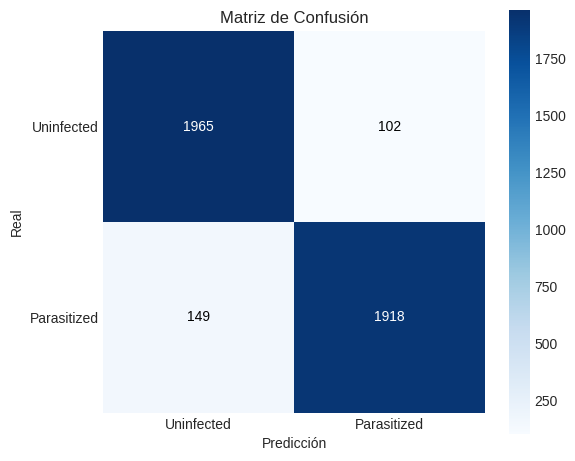

In [ ]:
# Evaluación del modelo en el conjunto de prueba y matriz de confusión

class_names = ['Uninfected', 'Parasitized']

# Predicciones
y_prob = model_cnn.predict(image_test.reshape(-1, 100, 100, 1))
y_pred = (y_prob >= 0.5).astype(int).flatten()

# Métricas
print("Evaluación en conjunto de prueba")
print(f"Accuracy: {accuracy_score(label_test, y_pred):.4f}\n")

print("Classification Report:")
print(classification_report(label_test, y_pred, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(label_test, y_pred)
print("Matriz de Confusión:")
print(cm)

plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de Confusión')
plt.colorbar()
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.grid(False)

thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

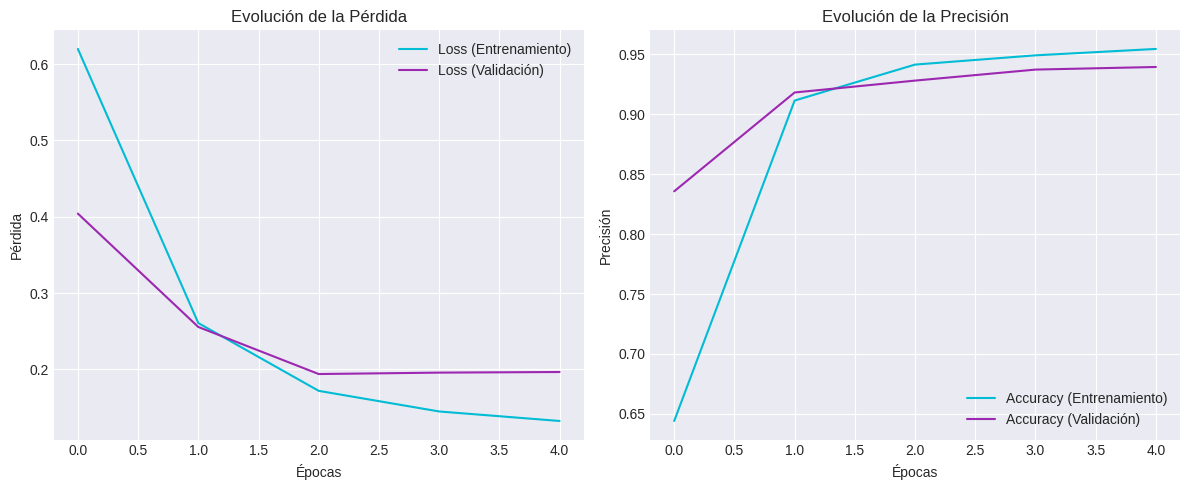

In [ ]:
# Gráficos de la evolución de pérdida y precisión (entrenamiento vs validación)
# Si val_loss sube mientras loss baja indica sobreajuste (overfitting)

plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(12, 5))

# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Loss (Entrenamiento)', color='#00BCD4')
plt.plot(history.history['val_loss'], label='Loss (Validación)',    color='#9C27B0')
plt.title('Evolución de la Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# Gráfico de precisión
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Accuracy (Entrenamiento)', color='#00BCD4')
plt.plot(history.history['val_accuracy'], label='Accuracy (Validación)',    color='#9C27B0')
plt.title('Evolución de la Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()

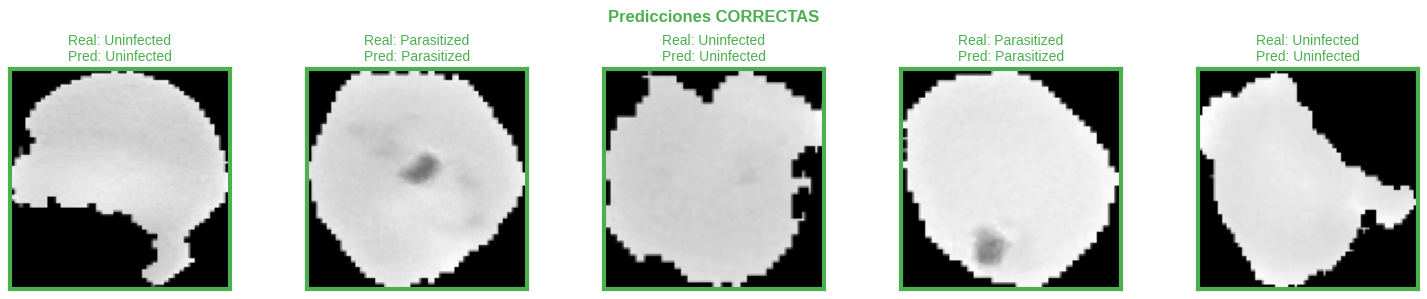

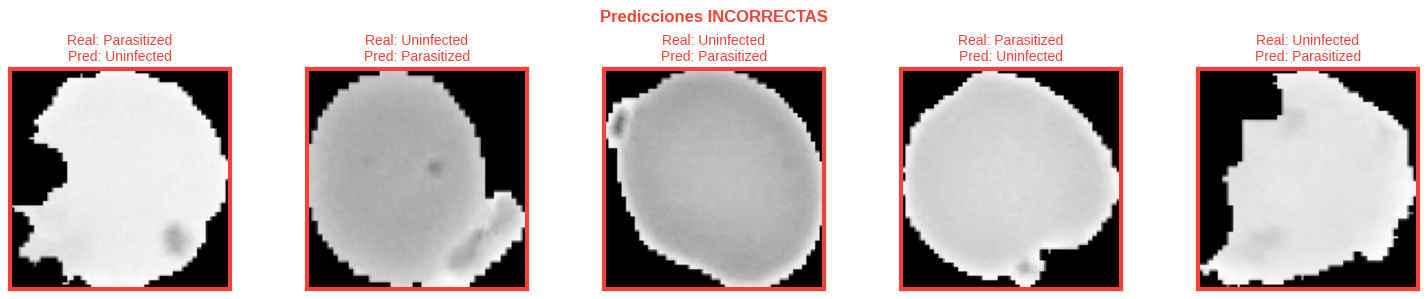

In [ ]:
# Ejemplos de predicciones

def mostrar_ejemplos(X, y_real, y_pred, correcto: bool, n=5):
    # para mostrar imágenes cuya predicción fue correcta y incorrecta
    mascara = (y_pred == y_real) if correcto else (y_pred != y_real)
    indices = np.where(mascara)[0]

    if len(indices) == 0:
        print("No hay ejemplos de este tipo.")
        return

    indices = indices[:n]
    titulo = "CORRECTAS" if correcto else "INCORRECTAS"
    color_borde = '#4CAF50' if correcto else '#F44336'  # verde o rojo

    fig, axes = plt.subplots(1, len(indices), figsize=(3 * len(indices), 3))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        ax.imshow(X[idx], cmap='gray')
        ax.set_title(
            f"Real: {class_names[y_real[idx]]}\n"
            f"Pred: {class_names[y_pred[idx]]}",
            fontsize=10,
            color=color_borde  # título en verde o rojo
        )
        # Borde de color alrededor de cada imagen
        for spine in ax.spines.values():
            spine.set_edgecolor(color_borde)
            spine.set_linewidth(3)
        ax.axis('on')
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f'Predicciones {titulo}', fontsize=12, fontweight='bold', color=color_borde)
    plt.tight_layout()
    plt.show()

mostrar_ejemplos(image_test, label_test, y_pred, correcto=True,  n=5)
mostrar_ejemplos(image_test, label_test, y_pred, correcto=False, n=5)

El modelo CNN desarrollado muestra buen rendimiento en la clasificación de células de malaria, alcanzando una precisión del 93.93% en el conjunto de prueba. Tanto la precisión como el recall se mantienen equilibrados entre las dos clases (Uninfected y Parasitized), con valores en torno al 93-95%, lo que indica que el modelo no presenta un sesgo significativo hacia ninguna de ellas. En la época 3 se aumenta un poco el error, por lo que más entrenamiento no mejoraría el modelo sino que empeoraría su capacidad de generalización.

Analizando las curvas de entrenamiento, se observa que la pérdida disminuye de forma consistente y la precisión converge rápidamente, sin signos claros de sobreajuste (probablemente gracias al uso de Dropout y EarlyStopping).

Respecto a los errores del modelo, los 149 falsos negativos (células parasitadas clasificadas como sanas) son los más críticos en un contexto médico, ya que implicarían no detectar una infección real. En las imágenes que se han clasificado incorrectamente, se observa que los fallos se producen soberetodo en células dónde las manchas del parásito son muy sutiles o de pequeño tamaño, lo que dificulta incluso su detección visual.

En cuanto a mejoras del modelo, se podría implementar el uso de imágenes en color (RGB) en lugar de escala de grises, ya que el parásito presenta una coloración que podrían aportar más datos al modelo.